In [1]:
from run_simulation import run_multiple_simulations, print_statistics
import numpy as np

num_permits = 6410
n_runs = 100
base_seed = 42

scenario = {
    "name": "standard_custom_non_like",
    "sequential": "standard",
    "pct_pre_approved": 0,
    "pct_custom": 1,
    "pct_self_cert": 0,
    "pct_like_for_like": 0,
}

print(f"Running {n_runs} simulations ({num_permits} permits each, collecting permits for analysis and plots)...")
results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=num_permits,
    inter_arrival_time=0,
    base_seed=base_seed,
    scenario_params_list=[scenario],
    collect_permits=True,
)

results_runs = results

run_mean_total = np.array(
    [r["stats"]["average_total_time"]["mean"] for r in results_runs],
    dtype=float,
)
run_median_total = np.array(
    [r["stats"]["average_total_time"]["median"] for r in results_runs],
    dtype=float,
)

print("\nAcross 100 runs — per-run mean total time (disaster → construction):")
print(f"  Mean:    {run_mean_total.mean():.2f} days")
print(f"  Median:  {np.median(run_mean_total):.2f} days")
print(f"  Std dev: {run_mean_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_mean_total.min():.2f} days")
print(f"  Max:     {run_mean_total.max():.2f} days")

print("\nAcross 100 runs — per-run median total time:")
print(f"  Mean:    {run_median_total.mean():.2f} days")
print(f"  Median:  {np.median(run_median_total):.2f} days")
print(f"  Std dev: {run_median_total.std(ddof=1):.2f} days")
print(f"  Min:     {run_median_total.min():.2f} days")
print(f"  Max:     {run_median_total.max():.2f} days")

# All permits from all 100 runs (for aggregate visualizations below)
all_permits = [p for r in results for p in r["permits"]]

print(f"\nCollected {len(all_permits)} permit records ({n_runs} runs × {num_permits} permits).")

print_statistics(results[0]["stats"])


Running 100 simulations (6410 permits each, collecting permits for analysis and plots)...

Across 100 runs — per-run mean total time (disaster → construction):
  Mean:    791.82 days
  Median:  792.13 days
  Std dev: 7.57 days
  Min:     773.67 days
  Max:     815.36 days

Across 100 runs — per-run median total time:
  Mean:    600.30 days
  Median:  599.92 days
  Std dev: 5.79 days
  Min:     586.55 days
  Max:     616.95 days

Collected 638783 permit records (100 runs × 6410 permits).

SIMULATION STATISTICS

Total Completed Permits: 6387
Total In Progress: 23

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   :    0 ( 0.00%)
  CUSTOM_NON_LIKE               : 6387 (100.00%)
  PRE_APPROVED_LIKE             :    0 ( 0.00%)
  PRE_APPROVED_NON_LIKE         :    0 ( 0.00%)
  SELF_CERT_LIKE                :    0 ( 0.00%)
  SELF_

In [2]:
# `results`: list of 100 run dicts (each has "stats", "permits", "seed", …).
# `all_permits`: all completed permits from all 100 runs (aggregate plots and random Gantt sampling).


In [ ]:
# Debris timing — default segment mix (re-run after changing permit_simulation / defaults)
# Segment mix is ``run_simulation()`` defaults: 2% pre-approved, 90% custom, 8% self-cert, 80% like-for-like.

from run_simulation import run_simulation
import numpy as np

# --- knobs ---
num_permits = 6410
inter_arrival_time = 0.0
n_mc = 25
base_seed = 42

mean_epa_calendar_days = []
usace_phase2_span_days = []

for k in range(n_mc):
    sim = run_simulation(
        num_permits=num_permits,
        random_seed=base_seed + k,
        inter_arrival_time=inter_arrival_time,
    )
    perms = sim.completed_permits

    # Regional disaster at simulation t=0; mean calendar day when EPA phase 1 finishes
    epa_ends = [p.epa_debris_end for p in perms if p.epa_debris_end is not None]
    if not epa_ends:
        raise RuntimeError("No EPA end times — check simulation output.")
    mean_epa_calendar_days.append(float(np.mean(epa_ends)))

    # USACE phase 2 cohort wall clock: first property USACE service start → last USACE end
    starts = [p.usace_debris_service_start for p in perms if p.usace_debris_service_start is not None]
    ends = [p.usace_debris_end for p in perms if p.usace_debris_end is not None]
    if not starts or not ends:
        raise RuntimeError("Missing USACE timestamps.")
    usace_phase2_span_days.append(float(max(ends) - min(starts)))

m_epa = float(np.mean(mean_epa_calendar_days))
s_epa = float(np.std(mean_epa_calendar_days, ddof=1)) if n_mc > 1 else 0.0
m_us = float(np.mean(usace_phase2_span_days))
s_us = float(np.std(usace_phase2_span_days, ddof=1)) if n_mc > 1 else 0.0

print(
    f"Cohort: {num_permits} permits, inter_arrival_time={inter_arrival_time}, "
    f"{n_mc} simulation(s), seeds {base_seed}..{base_seed + n_mc - 1}"
)
print()
print(
    "1) Mean calendar days from disaster (t=0) until EPA phase 1 complete "
    "(average of epa_debris_end across properties; then mean across runs if n_mc>1):"
)
print(f"   {m_epa:.2f} days" + (f"  (std across runs: {s_epa:.2f})" if n_mc > 1 else ""))
print()
print(
    "2) USACE phase 2 total duration: min(usace service start) → max(usace end) "
    "(one value per run; mean across runs if n_mc>1):"
)
print(f"   {m_us:.2f} days" + (f"  (std across runs: {s_us:.2f})" if n_mc > 1 else ""))


In [3]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in all_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 4640 (CUSTOM_NON_LIKE): 117.53 days total, 1 re-checks
  Permit 3455 (CUSTOM_NON_LIKE): 121.16 days total, 1 re-checks
  Permit 2025 (CUSTOM_NON_LIKE): 122.08 days total, 1 re-checks
  Permit 5588 (CUSTOM_NON_LIKE): 128.60 days total, 1 re-checks
  Permit 1062 (CUSTOM_NON_LIKE): 137.04 days total, 1 re-checks


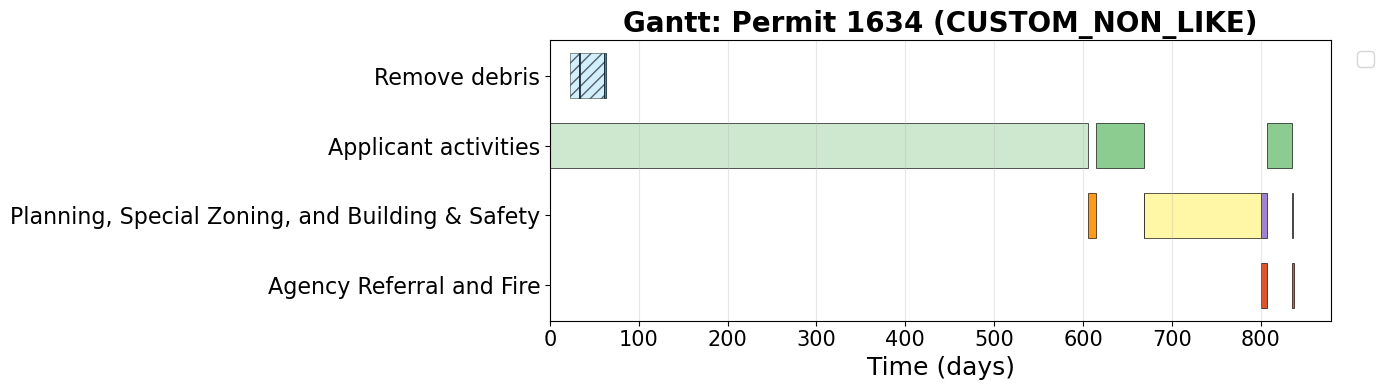

In [4]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_one_random_permit_segment
import matplotlib.pyplot as plt

fig, ax = plot_gantt_one_random_permit_segment(
    all_permits,
    segment_value=4,
    random_seed=100,
    figsize=(14, 4),
)
if fig:
    plt.show()

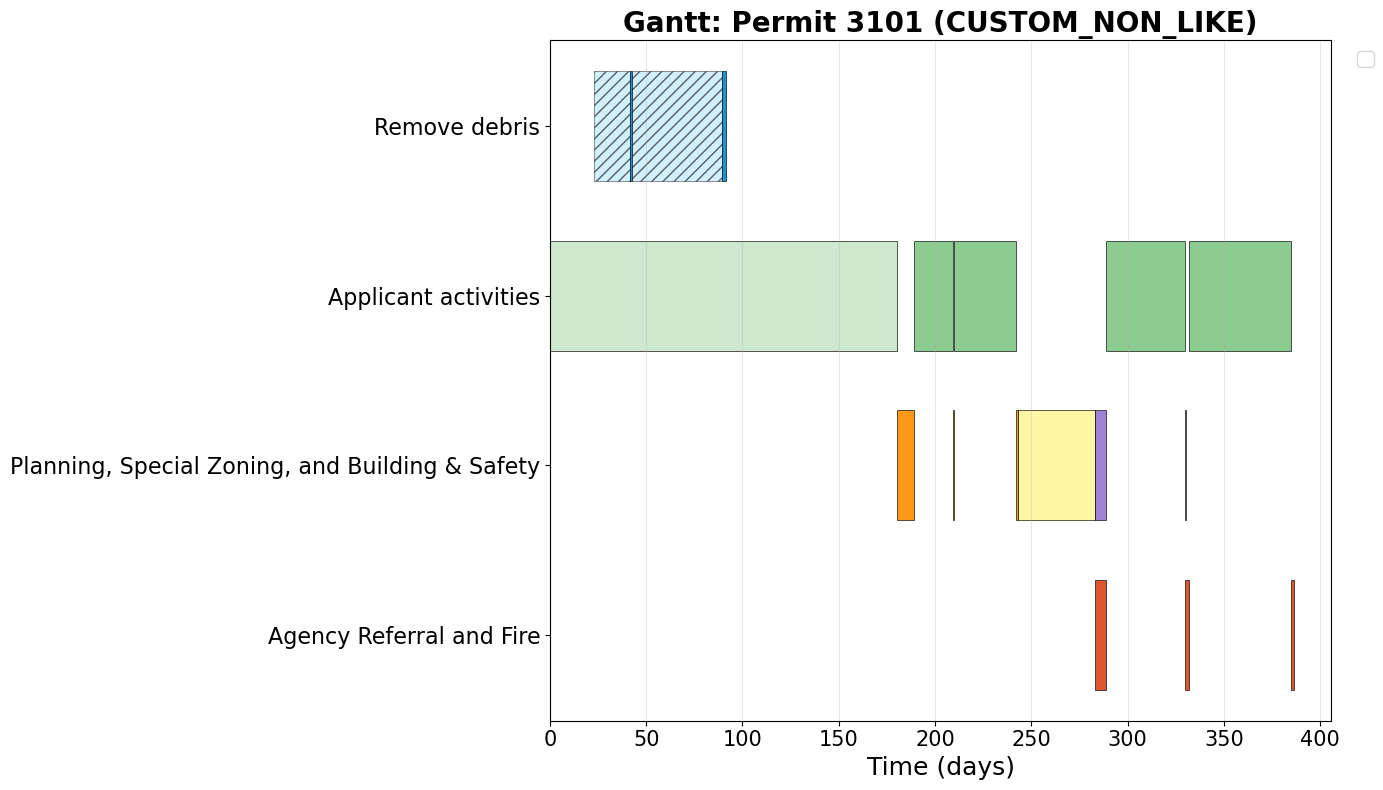

In [5]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt
import random

# One random run from the 100, same list index as before (representative Gantt)
_run = random.Random(42).choice(results)
fig, ax = plot_gantt_single_permit(
    _run["permits"][1460],
    figsize=(14, 8), 
)
if fig:
    plt.show()

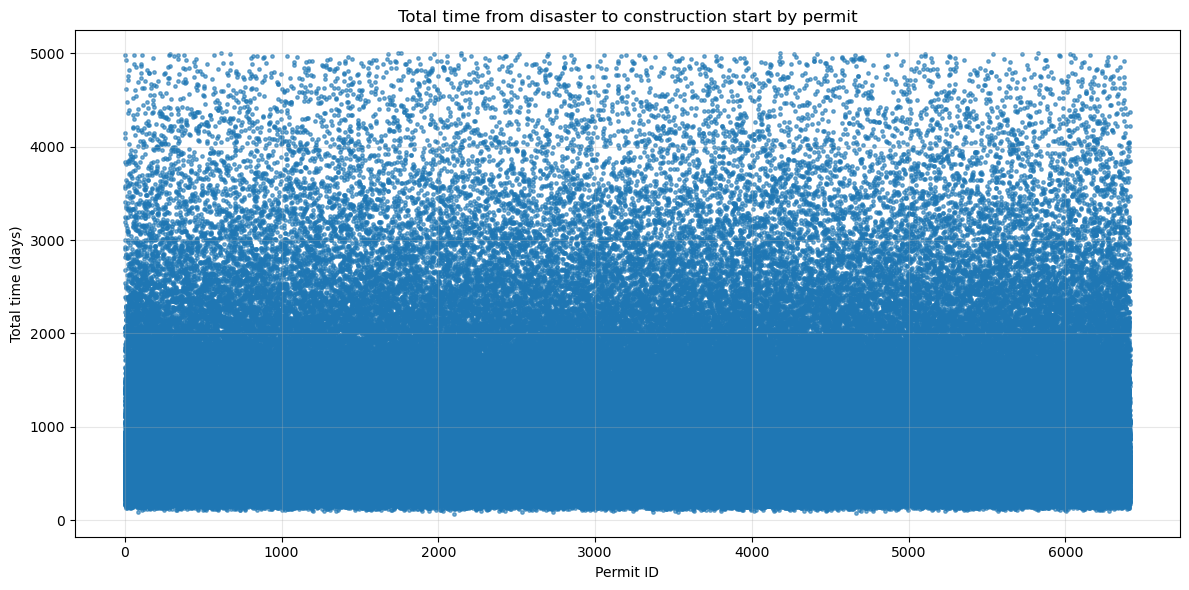

In [6]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in all_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

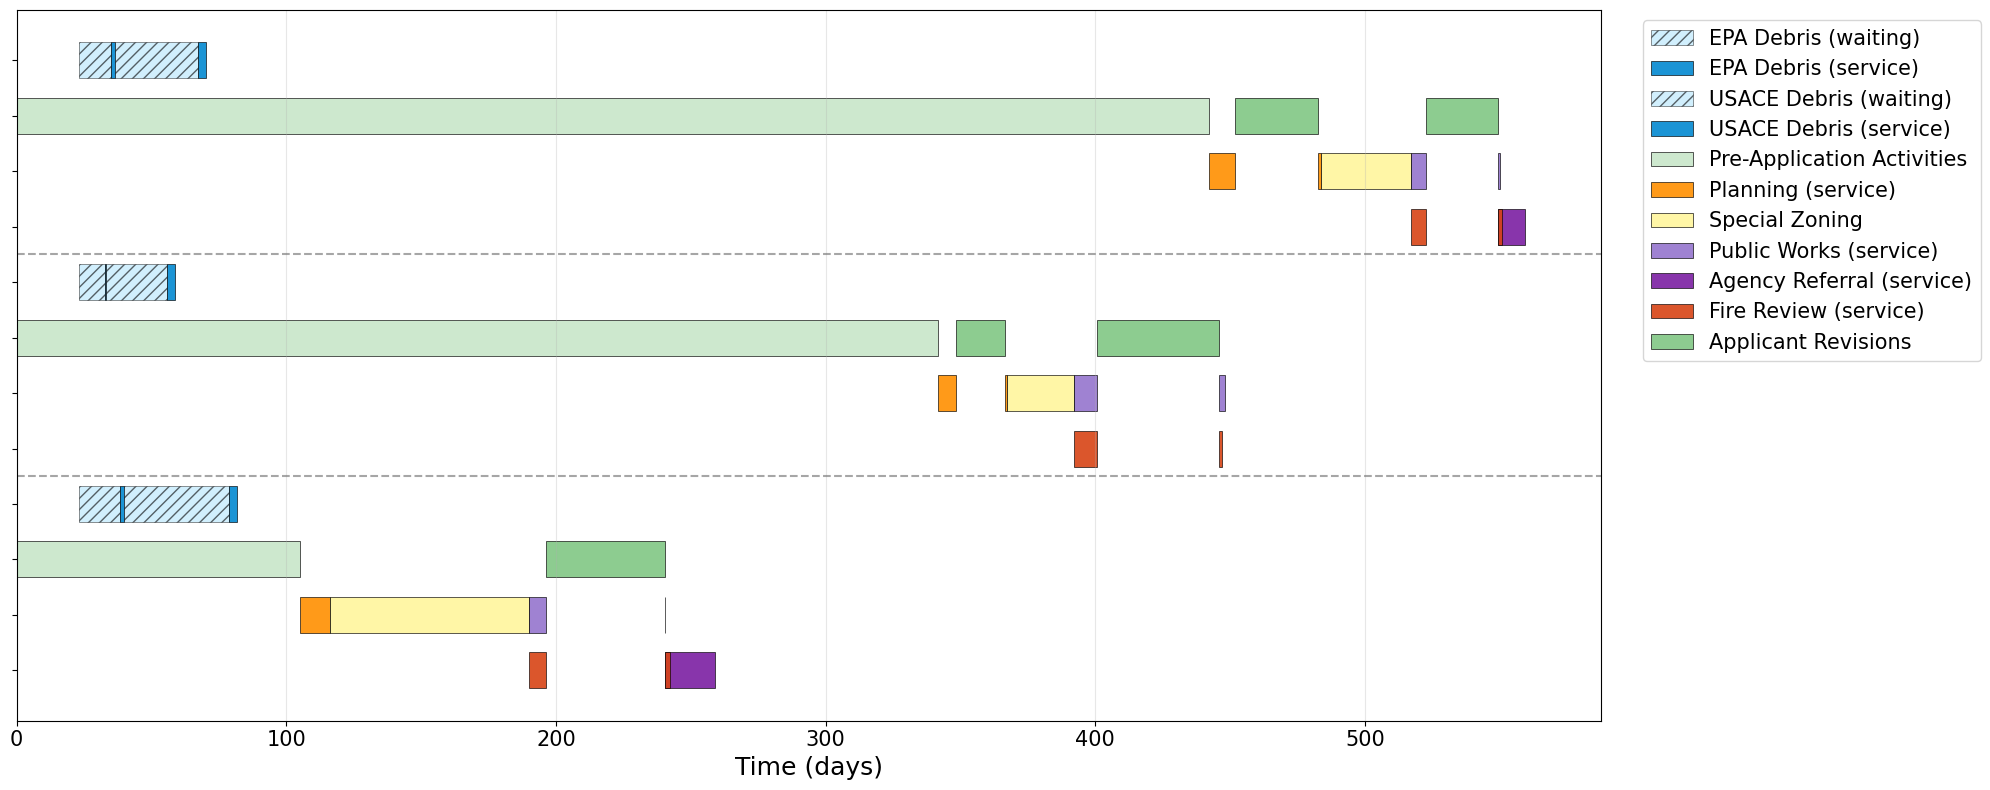

In [7]:
# Gantt chart for 3 random permits
from visualize_permits import plot_gantt_three_random_permits
import matplotlib.pyplot as plt

fig, ax = plot_gantt_three_random_permits(
    all_permits,
    random_seed=36,
    figsize=(20, 8),
)
if fig:
    plt.show()

Average waiting and service time by step (days):
  EPA Debris: waiting mean=19.50, σ=11.60; service mean=1.00, σ=0.49
  USACE Debris: waiting mean=48.02, σ=28.27; service mean=2.50, σ=0.50
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=637.43, σ=615.31
  Planning: waiting mean=0.00, σ=0.00; service mean=10.00, σ=1.21
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=57.37, σ=45.44
  Public Works: waiting mean=0.00, σ=0.00; service mean=9.00, σ=2.11
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=38.30, σ=30.41
  Fire Review: waiting mean=0.00, σ=0.00; service mean=4.68, σ=3.56
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=63.55, σ=23.70


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

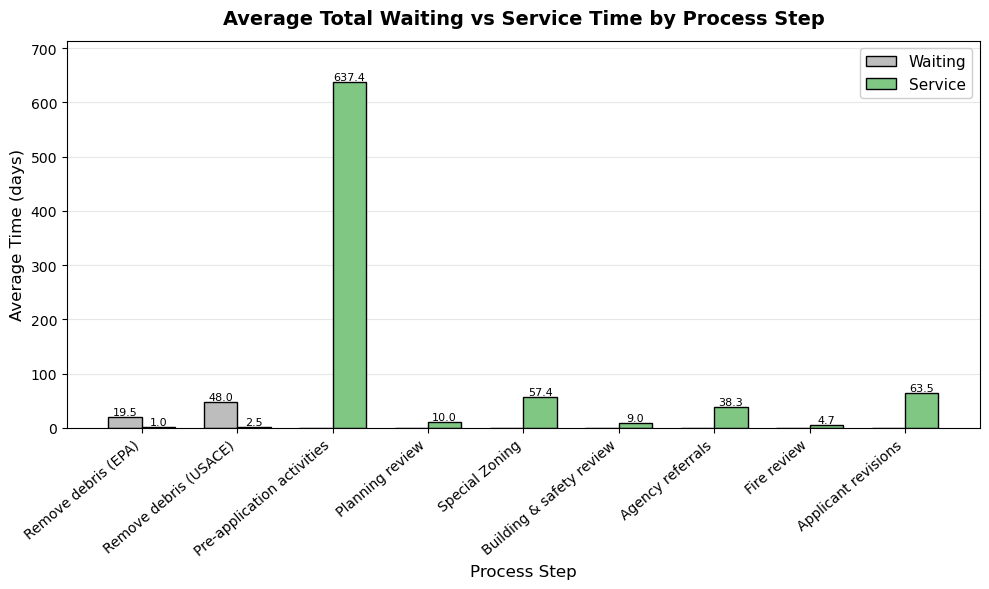

In [8]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Pre-Application Activities": "Pre-application activities",
    "Planning": "Planning review",
    "Special Zoning Review": "Special zoning review",
    "Public Works": "Building & safety review",
    "Agency Referral": "Agency referrals",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}
plot_average_waiting_and_service_by_step(all_permits, label_map=label_map)


Calculate statistics to understand the amount of time between the end of debris removal and plan submission

In [9]:
import statistics

deltas = [
    p.plan_prep_end - p.debris_removal_end
    for p in all_permits
    if p.plan_prep_end is not None and p.debris_removal_end is not None
]

statistics.mean(deltas), statistics.median(deltas)

(np.float64(543.4200372545159), np.float64(350.07809362107514))

In [10]:
starts = [p.epa_debris_service_start for p in all_permits if p.epa_debris_service_start is not None]
ends = [p.epa_debris_end for p in all_permits if p.epa_debris_end is not None]
if starts and ends:
    span = max(ends) - min(starts)  # first start → last end
    print("First EPA start:", min(starts), "Last EPA end:", max(ends), "Span:", span)

First EPA start: 23 Last EPA end: 65.45874653889085 Span: 42.45874653889085
